# Testing our equation to La Jara data 

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error
import itertools

### Model Functions

In [2]:
def evolve_tauc_tc(
    tau_star,           # array of Shields stress τ*(t)
    dt,                 # timestep between τ* samples
    tau_c_min,          # minimum τ*c global
    tau_c_max,          # maximum τ*c global
    event_indices,      # time labels or integer positions where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    multiplicative_factor=1, # factor to adjust k values (e.g., for sensitivity testing)
    A=0.2924,
    B=8.6866
):

    # convert τ* to numeric 1D array and keep index if Series
    if isinstance(tau_star, pd.Series):
        tau_index = tau_star.index
        tau_star_vals = tau_star.to_numpy(dtype=float)
    else:
        tau_index = None
        tau_star_vals = np.asarray(tau_star, dtype=float)

    if tau_star_vals.ndim != 1:
        raise ValueError("tau_star must be 1D after conversion")

    # convert event indices to integer positions in tau_star_vals
    event_labels = np.asarray(event_indices)
    if tau_index is not None:
        event_pos = tau_index.get_indexer(event_labels)

        # allow an initialization observation before forcing starts (e.g., event 0 while tau index starts at 1)
        missing_mask = event_pos < 0
        if np.any(missing_mask) and np.issubdtype(event_labels.dtype, np.number):
            before_start = missing_mask & (event_labels < tau_index.min())
            event_pos[before_start] = 0

        if np.any(event_pos < 0):
            missing_labels = event_labels[event_pos < 0]
            raise ValueError(f"some event indices are not in tau_star index: {missing_labels}")
    else:
        event_pos = np.asarray(event_indices, dtype=int)

    # keep only observed τ*c values that are not NaN
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    valid_obs_mask = ~np.isnan(tau_c_obs_arr)
    event_pos_valid = event_pos[valid_obs_mask]
    tau_c_obs_valid = tau_c_obs_arr[valid_obs_mask]

    # initialize modeled τ*c, τ*c_eq, and k array
    n = len(tau_star_vals)
    tau_c = np.full(n, np.nan, dtype=float)  # nan means τ*c is undefined (e.g., during gaps)
    tau_c_pot = np.full(n, np.nan, dtype=float)
    k_array = np.full(n, np.nan, dtype=float)
    tauc_ratio = np.full(n, np.nan, dtype=float)
    tau_conv_array = np.full(n, np.nan, dtype=float)

    tau_c_obs_dict = dict(zip(event_pos_valid, tau_c_obs_valid))
    was_in_gap = True

    i = 0
    while i < n-1:
        # determine current τ*
        t = tau_star_vals[i]  # current τ*

        # k equation parameters from flume data
        k = A * (t / tau_c_max) ** B

        # initialize τ*c when observation exists
        if was_in_gap and i in tau_c_obs_dict:
            tau_c_current = tau_c_obs_dict[i]
            tau_c[i] = tau_c_current
            was_in_gap = False
        else:
            tau_c_current = tau_c[i]

        # calculate transport capacity 
        tc = t/tau_c_current  # transport capacity
        tauc_ratio[i] = tc

        # calculate potential τ*c based on current τ*/τ*c
        ks = 50
        xs = 0.79
        kw = 3.7
        if tc <= 1:
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) / (1 + np.exp(-ks * (tc - xs)))
            tau_pot = max(tau_c_current, tau_conv)  # τ*c cannot decrease below current value if τ* is low
            tau_pot_pure = tau_conv
        else:  # otherwise, equilibrium is given by the weakening function
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) * (tc) ** (-kw)
            tau_pot = tau_conv
            tau_pot_pure = tau_conv

        k_array[i] = k
        tau_c_pot[i] = tau_pot_pure
        tau_conv_array[i] = tau_pot

        # evolve τ*c with new equation
        tau_c[i+1] = tau_conv_array[i] - (tau_conv_array[i] - tau_c[i]) * np.exp(-k * multiplicative_factor * dt)
        #print('tauc at time:', i, 'is', tau_c[i], '. tau/tauc', tauc_ratio[i], 'and tau_pot is', tau_c_pot[i], 'with k', k_array[i])
        i += 1

    return tau_c, k_array, tau_c_pot, tauc_ratio

parameter calibration 

In [3]:
def calibrate_parameters(
    tau_star,
    event_indices,      # indices of event start times
    tau_c_obs,          # observed τ*c at events
    dt,
    tau_c_max,
    tau_c_min,
    A_vals,             # candidate values for parameter A
    B_vals,             # candidate values for parameter B
):
    
    """
    Grid-search calibration of the model using mean absolute error (MAE).
    """
    results = []
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    
    # iterate through minimum τ*c values, and A and B parameters
    for a_idx, A in enumerate(A_vals):
        print(f"Testing A = {A:.6e} ({a_idx + 1}/{len(A_vals)})")
        for b_idx, B in enumerate(B_vals):
            print(f"Testing B = {B:.6e} ({b_idx + 1}/{len(B_vals)})")
            tau_c_model, *_ = evolve_tauc_tc(
                tau_star=tau_star,
                dt=dt,
                tau_c_min=tau_c_min,
                tau_c_max=tau_c_max,
                event_indices=event_indices,
                tau_c_obs=tau_c_obs,
                A=A,
                B=B,
            )

            # extract modeled τ*c at event starts
            if isinstance(tau_star, pd.Series):
                tau_c_series = pd.Series(tau_c_model, index=tau_star.index)
                tau_c_pred = tau_c_series.reindex(event_indices).to_numpy(dtype=float)
            else:
                event_pos = np.asarray(event_indices, dtype=int)
                tau_c_pred = np.asarray(tau_c_model, dtype=float)[event_pos]

            # calculate mean absolute error (paper uses MAE), and ignore NaNs
            mae = np.nanmean(np.abs(tau_c_pred - tau_c_obs_arr))
            results.append({
                "A": A,
                "B": B,
                "tau_c_min": tau_c_min,
                "MAE": mae
            })

    expected = len(A_vals) * len(B_vals)
    if len(results) != expected:
        raise RuntimeError(f"Expected {expected} calibration rows, got {len(results)}")

    return results

### Testing Field Data

Import Data

In [11]:
# import data 
tau_star = pd.read_csv('../../../shear_stress_record/average_shear_stress_lajara_full.csv')
tauc_events = pd.read_csv('../field_data/tauc_events_exceedance_rising.csv', parse_dates=['datetime'], index_col='datetime')
# convert to datetime and set as index
tau_star['datetime'] = pd.to_datetime(tau_star['datetime']) 
tau_star = tau_star.set_index('datetime')

df_tau_resampled = tau_star.resample('1min').ffill()  # forwardfill to keep tau* constant during gaps
# create continuous 1-minute time index from first timestamp to last
continuous_index = pd.date_range(start=tau_star.index.min(), end=tau_star.index.max(), freq='1min')

# change column name to 'tau' for clarity
df_tau = tau_star.rename(columns={'shear_stress': 'tau'})
# delete everything before 2022-07-14 (we don't care about earlier times)
df_tau = df_tau[df_tau.index >= '2022-07-14 15:00']


print(f"Data gaps (NaNs): {df_tau['tau'].isna().sum().sum()}")
# show what dates are the data gaps
print("Data gaps (NaN indices):", df_tau[df_tau['tau'].isna()].index)

# convert tau to dimenstionless Shields stress τ*
rho_s = 2650.0  # sediment density, kg/m3
rho = 1000.0   # fluid density, kg/m3
g = 9.81       # gravitational acceleration, m/s2
d50 = 0.04364    # median grain diameter, m

df_tau['tau_star'] = df_tau['tau'] / ((rho_s - rho) * g * d50)

# build integer index mapping
time_to_index = pd.Series(
    np.arange(len(df_tau)), 
    index=df_tau.index
)
event_indices = time_to_index.loc[tauc_events.index].to_numpy() # integer indices of event times
tau_c_obs = tauc_events["tauc"].to_numpy() # observed τ*c values
tau_star = df_tau["tau_star"].to_numpy() # τ* time series array

# calculate dt in minutes (should be 15)
dt = (df_tau.index[1] - df_tau.index[0]).total_seconds() / 60
print(f"Calculated dt: {dt} minutes")

Data gaps (NaNs): 0
Data gaps (NaN indices): DatetimeIndex([], dtype='datetime64[ns]', name='datetime', freq=None)
Calculated dt: 15.0 minutes


Run Full La Jara Record

In [13]:
tauc_obs_lajara = tauc_events["tauc"].to_numpy()
# find min and max of τ*c observations 
tauc_min_lajara = tauc_obs_lajara.min() * 0.9
tauc_max_lajara = tauc_obs_lajara.max() * 1.01

In [12]:
tauc_min_lajara

np.float64(0.087875928)

#### First Iteration: dt=15

In [ ]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 100) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_min_lajara = 0.034
tauc_max_lajara = 0.34

In [73]:
calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=15,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/100)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.95918

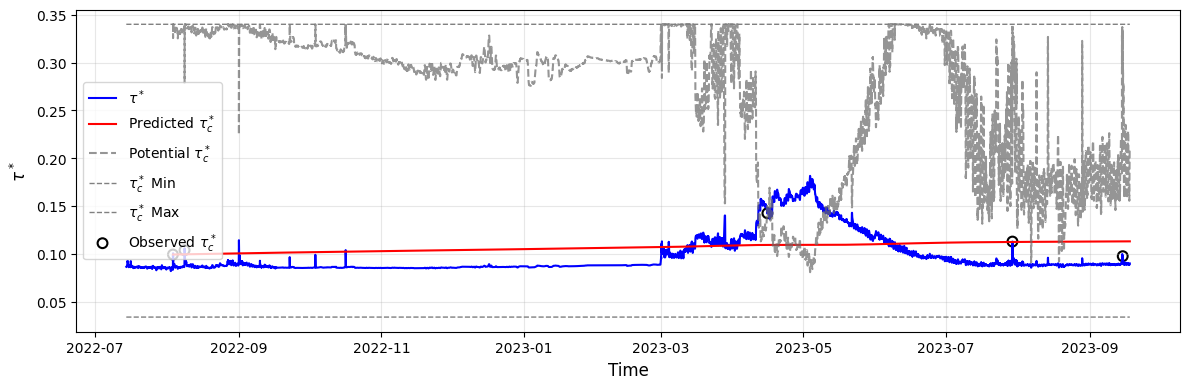

In [74]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=15, # 15 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Sensitivity Analysis

Best MAE: 0.006321
10% threshold (<=): 0.006953
Parameter sets within threshold: 9 / 5000


,tau_c_min,A,B,MAE
0,0.07,0.000050,3.061224,0.006321
1,0.07,0.000057,3.061224,0.006386
2,0.07,0.000043,3.061224,0.006464
3,0.07,0.000066,3.061224,0.006565
4,0.07,0.000076,4.081633,0.006713
5,0.07,0.000038,3.061224,0.006717
6,0.07,0.000087,4.081633,0.006760
7,0.07,0.000076,3.061224,0.006831
8,0.07,0.000066,4.081633,0.006888


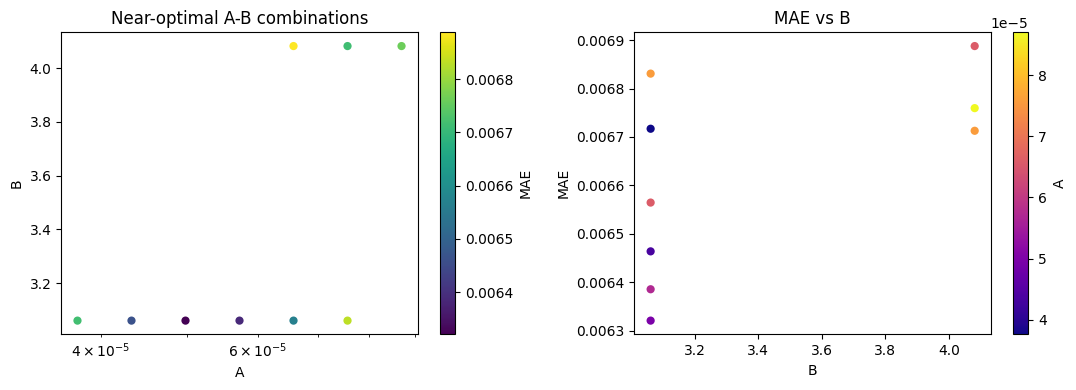

In [71]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/tc_min_0.070.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

#### Second Iteration: dt= 1

In [12]:
# change column name to 'tau' for clarity
df_tau_resampled = df_tau_resampled.rename(columns={'shear_stress': 'tau'})
# delete everything before 2022-07-14 (we don't care about earlier times)
df_tau_resampled = df_tau_resampled[df_tau_resampled.index >= '2022-07-14 15:00']

print(f"Data gaps (NaNs): {df_tau_resampled['tau'].isna().sum().sum()}")
# show what dates are the data gaps
print("Data gaps (NaN indices):", df_tau_resampled[df_tau_resampled['tau'].isna()].index)

# convert tau to dimenstionless Shields stress τ*
rho_s = 2650.0  # sediment density, kg/m3
rho = 1000.0   # fluid density, kg/m3
g = 9.81       # gravitational acceleration, m/s2
d50 = 0.04364    # median grain diameter, m

df_tau_resampled['tau_star'] = df_tau_resampled['tau'] / ((rho_s - rho) * g * d50)

# build integer index mapping
time_to_index = pd.Series(
    np.arange(len(df_tau_resampled)), 
    index=df_tau_resampled.index
)
event_indices = time_to_index.loc[tauc_events.index].to_numpy() # integer indices of event times
tau_c_obs = tauc_events["tauc"].to_numpy() # observed τ*c values
tau_star = df_tau_resampled["tau_star"].to_numpy() # τ* time series array

# calculate dt in minutes (should be 15)
dt = (df_tau_resampled.index[1] - df_tau_resampled.index[0]).total_seconds() / 60
print(f"Calculated dt: {dt} minutes")

Data gaps (NaNs): 0
Data gaps (NaN indices): DatetimeIndex([], dtype='datetime64[ns]', name='datetime', freq='min')
Calculated dt: 1.0 minutes


0.08

In [18]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 100) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.08


In [19]:
calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/100)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.95918

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


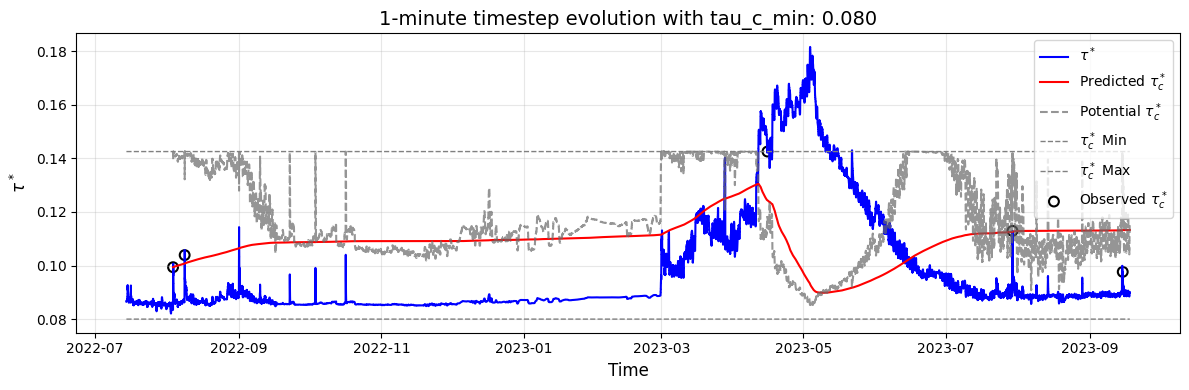

In [20]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.007452
10% threshold (<=): 0.008197
Parameter sets within threshold: 15 / 5000


,tau_c_min,A,B,MAE
0,0.08,0.000057,5.102041,0.007452
1,0.08,0.000066,5.102041,0.007565
2,0.08,0.000043,4.081633,0.007671
3,0.08,0.000038,4.081633,0.007698
4,0.08,0.000050,4.081633,0.007730
5,0.08,0.000050,5.102041,0.007731
6,0.08,0.000033,4.081633,0.007780
7,0.08,0.000057,4.081633,0.007901
8,0.08,0.000028,4.081633,0.007903
9,0.08,0.000087,6.122449,0.007913


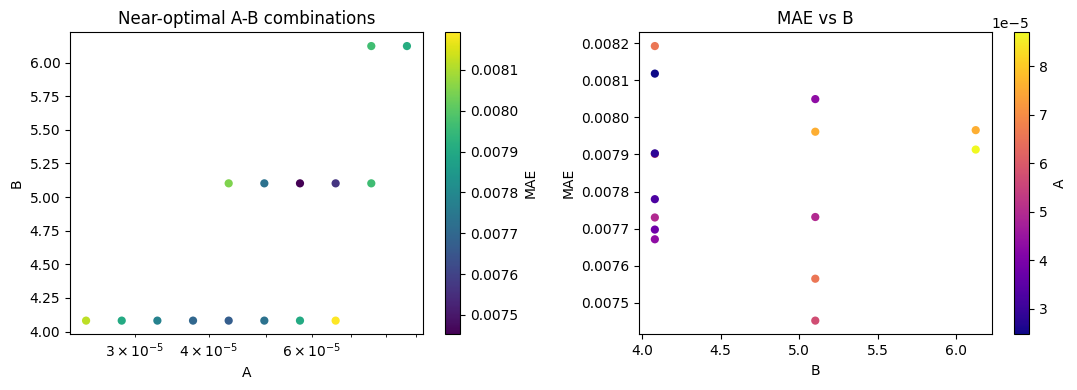

In [21]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.080.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.07

In [22]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.07

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


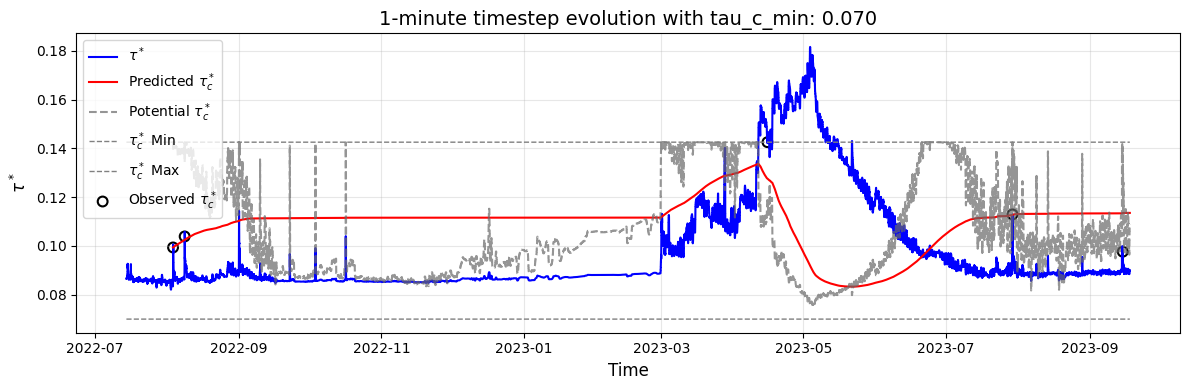

In [23]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.006515
10% threshold (<=): 0.007167
Parameter sets within threshold: 6 / 2000


,tau_c_min,A,B,MAE
0,0.07,0.000049,3.061224,0.006515
1,0.07,0.000070,3.061224,0.006874
2,0.07,0.000049,2.040816,0.006962
3,0.07,0.000070,4.081633,0.007096
4,0.07,0.000035,3.061224,0.007113
5,0.07,0.000035,2.040816,0.007116


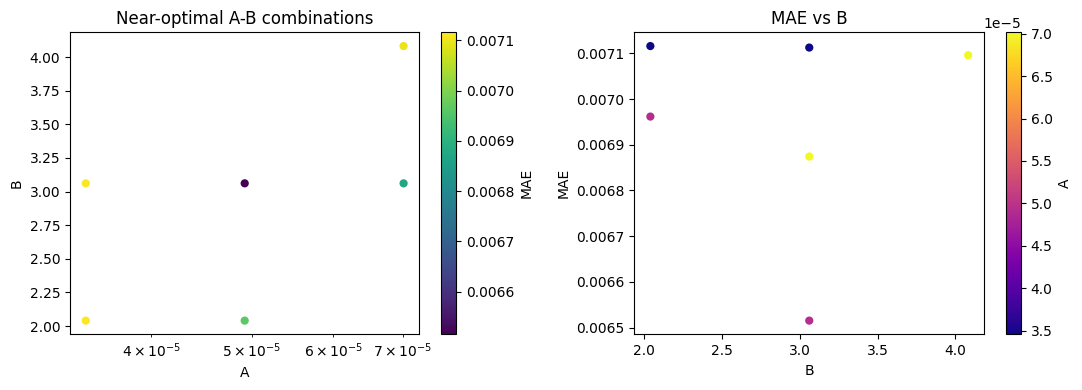

In [24]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.070.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.071

In [25]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.071

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


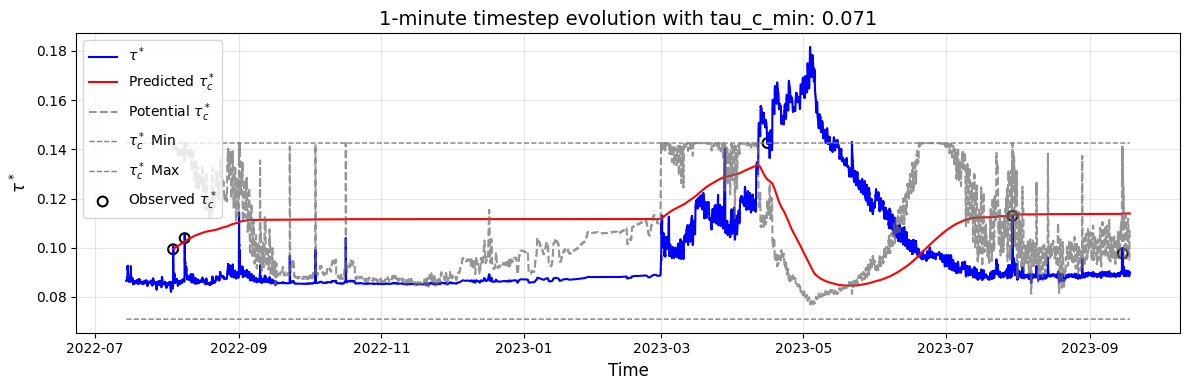

In [26]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.006546
10% threshold (<=): 0.007201
Parameter sets within threshold: 5 / 2000


,tau_c_min,A,B,MAE
0,0.071,0.000049,3.061224,0.006546
1,0.071,0.000070,4.081633,0.007002
2,0.071,0.000070,3.061224,0.007016
3,0.071,0.000035,3.061224,0.007047
4,0.071,0.000049,2.040816,0.007180


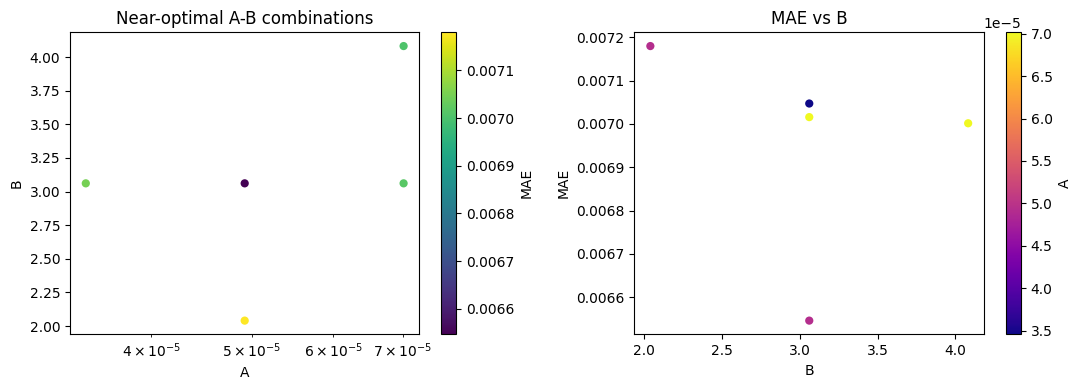

In [27]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.071.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.072

In [28]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.072

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


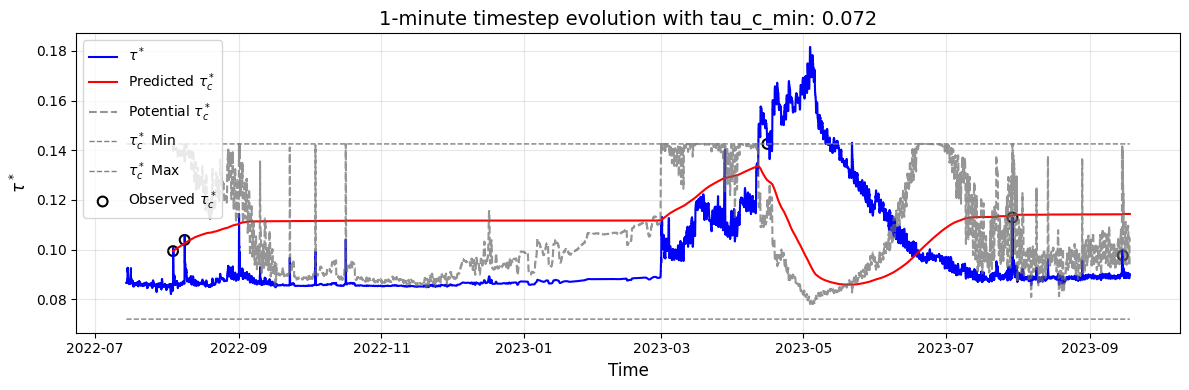

In [29]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.006705
10% threshold (<=): 0.007375
Parameter sets within threshold: 4 / 2000


,tau_c_min,A,B,MAE
0,0.072,0.000049,3.061224,0.006705
1,0.072,0.000070,4.081633,0.006918
2,0.072,0.000035,3.061224,0.006988
3,0.072,0.000070,3.061224,0.007196


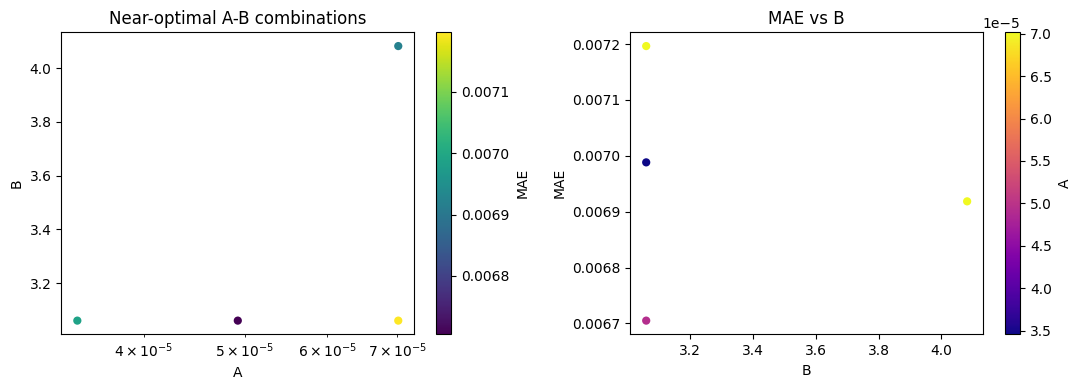

In [30]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.072.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.073

In [31]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.073

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


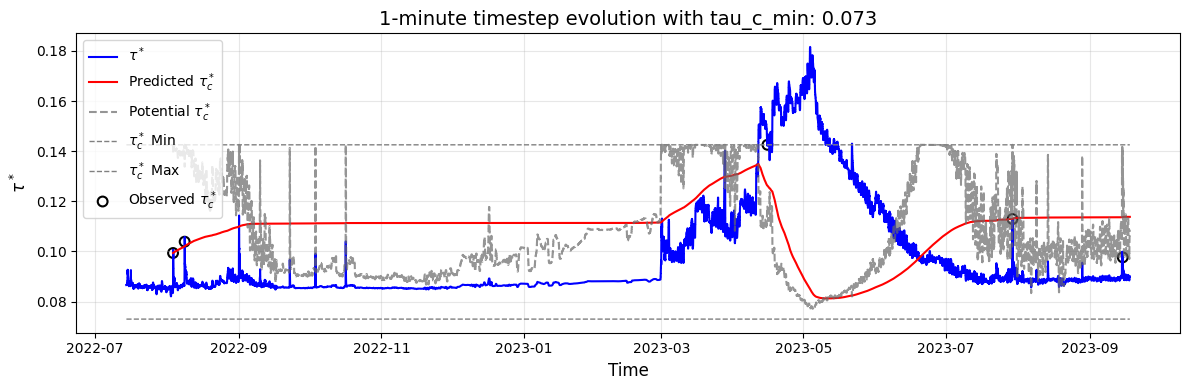

In [32]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.006876
10% threshold (<=): 0.007564
Parameter sets within threshold: 5 / 2000


,tau_c_min,A,B,MAE
0,0.073,0.000070,4.081633,0.006876
1,0.073,0.000049,3.061224,0.006877
2,0.073,0.000035,3.061224,0.007019
3,0.073,0.000049,4.081633,0.007367
4,0.073,0.000070,3.061224,0.007407


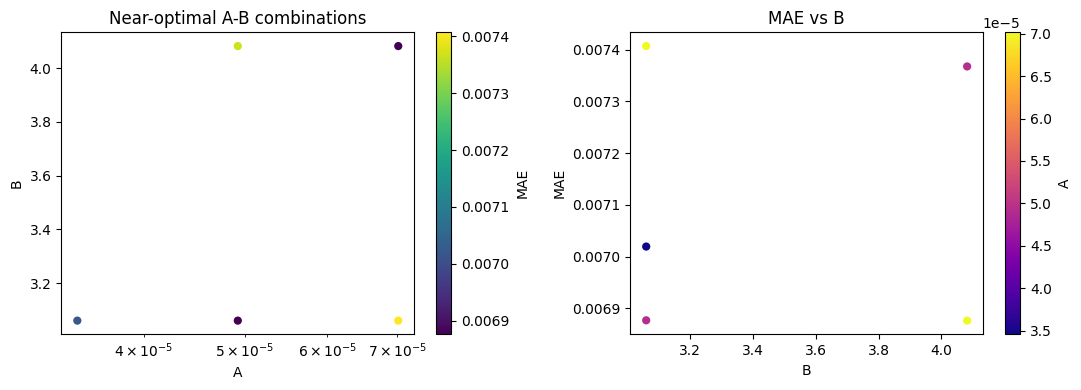

In [33]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.073.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.074

In [34]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.074

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


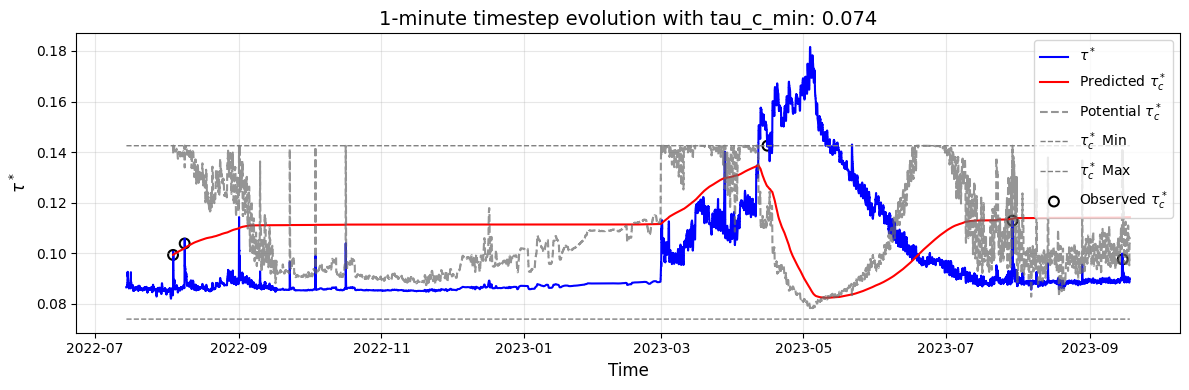

In [35]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.007040
10% threshold (<=): 0.007743
Parameter sets within threshold: 6 / 2000


,tau_c_min,A,B,MAE
0,0.074,0.000070,4.081633,0.007040
1,0.074,0.000049,3.061224,0.007063
2,0.074,0.000035,3.061224,0.007202
3,0.074,0.000049,4.081633,0.007252
4,0.074,0.000070,3.061224,0.007631
5,0.074,0.000024,3.061224,0.007697


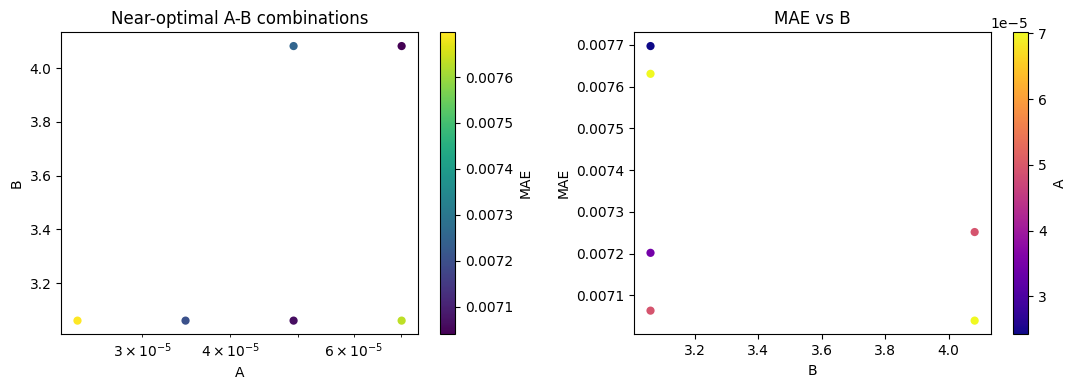

In [36]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.074.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.075

In [37]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.075

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


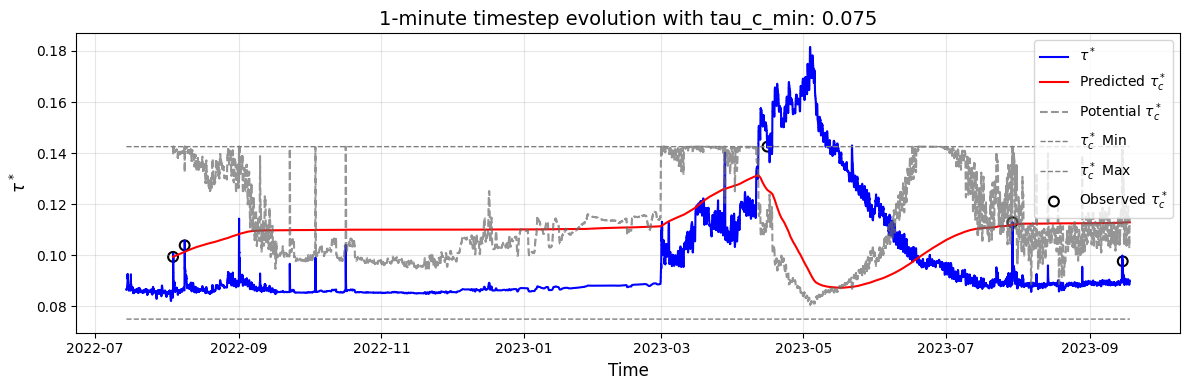

In [38]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.007159
10% threshold (<=): 0.007875
Parameter sets within threshold: 6 / 2000


,tau_c_min,A,B,MAE
0,0.075,0.000049,4.081633,0.007159
1,0.075,0.000070,4.081633,0.007220
2,0.075,0.000049,3.061224,0.007259
3,0.075,0.000035,3.061224,0.007391
4,0.075,0.000070,5.102041,0.007667
5,0.075,0.000070,3.061224,0.007864


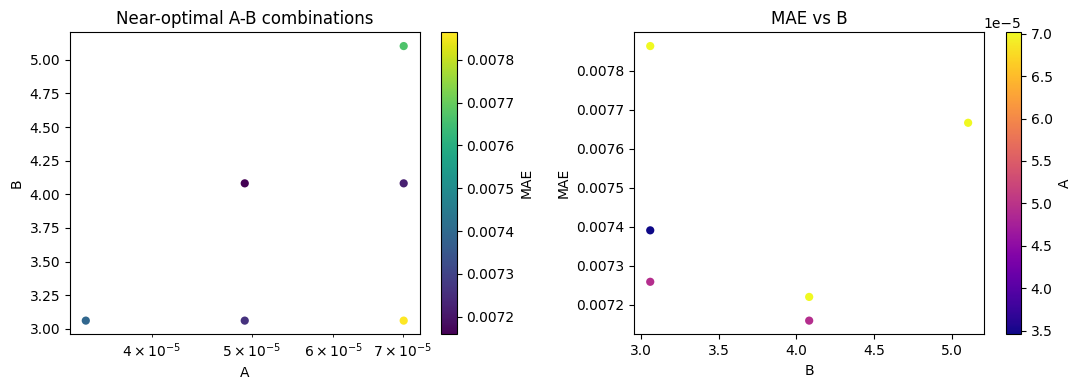

In [39]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.075.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.076

In [40]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.076

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


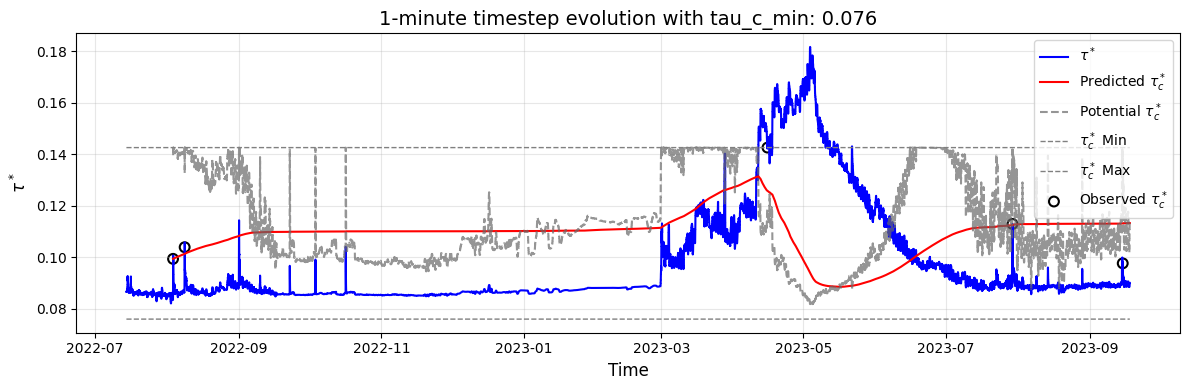

In [41]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.007078
10% threshold (<=): 0.007786
Parameter sets within threshold: 5 / 2000


,tau_c_min,A,B,MAE
0,0.076,0.000049,4.081633,0.007078
1,0.076,0.000070,4.081633,0.007418
2,0.076,0.000049,3.061224,0.007479
3,0.076,0.000070,5.102041,0.007530
4,0.076,0.000035,3.061224,0.007597


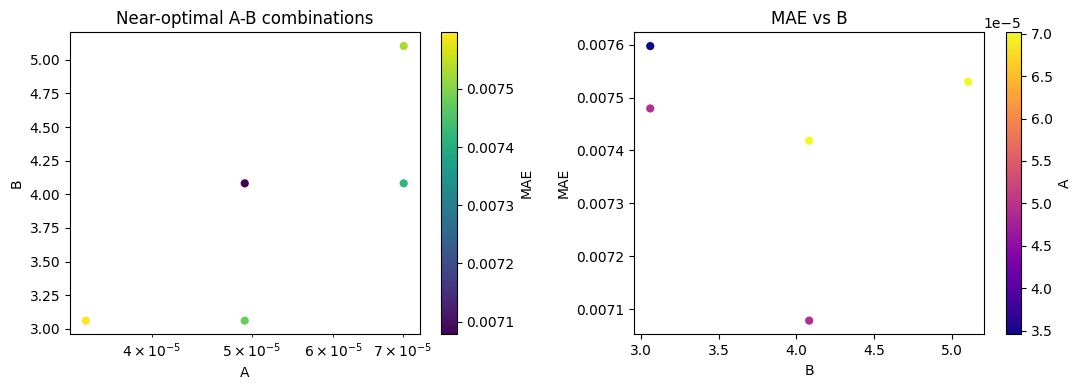

In [42]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.076.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.077

In [43]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.077

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


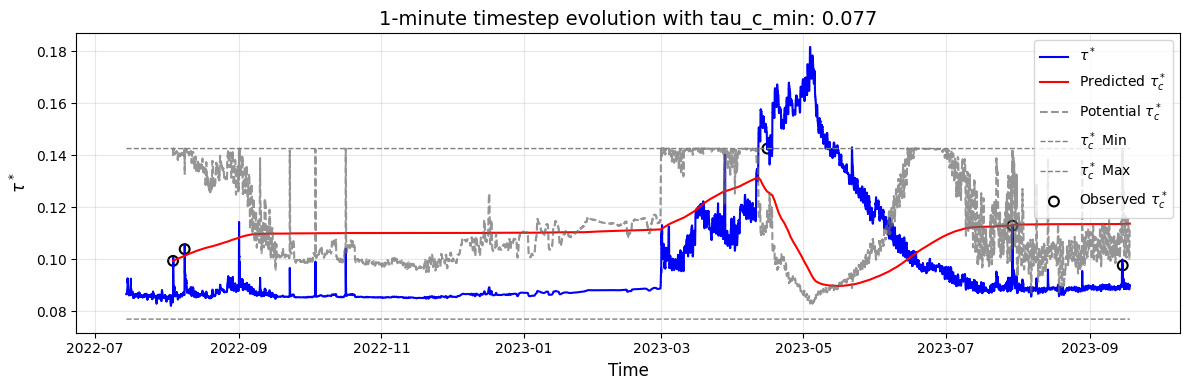

In [44]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.007067
10% threshold (<=): 0.007773
Parameter sets within threshold: 5 / 2000


,tau_c_min,A,B,MAE
0,0.077,0.000049,4.081633,0.007067
1,0.077,0.000070,5.102041,0.007417
2,0.077,0.000070,4.081633,0.007627
3,0.077,0.000035,4.081633,0.007693
4,0.077,0.000049,3.061224,0.007714


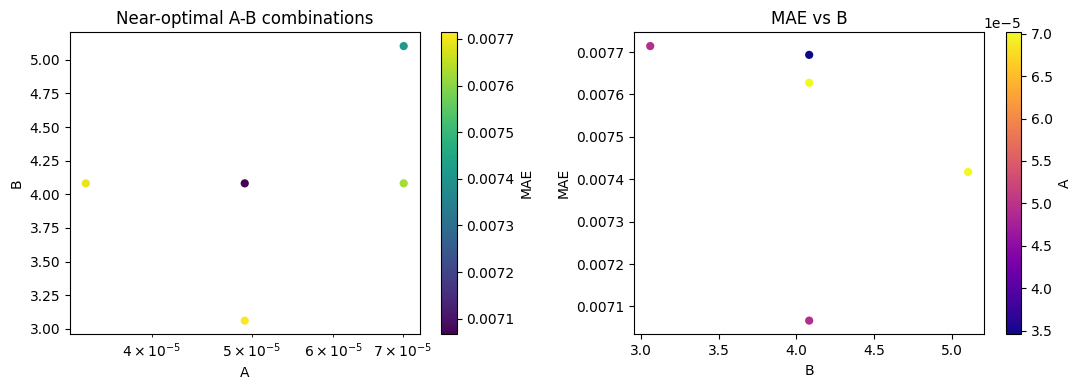

In [45]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.077.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.078

In [46]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.078

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


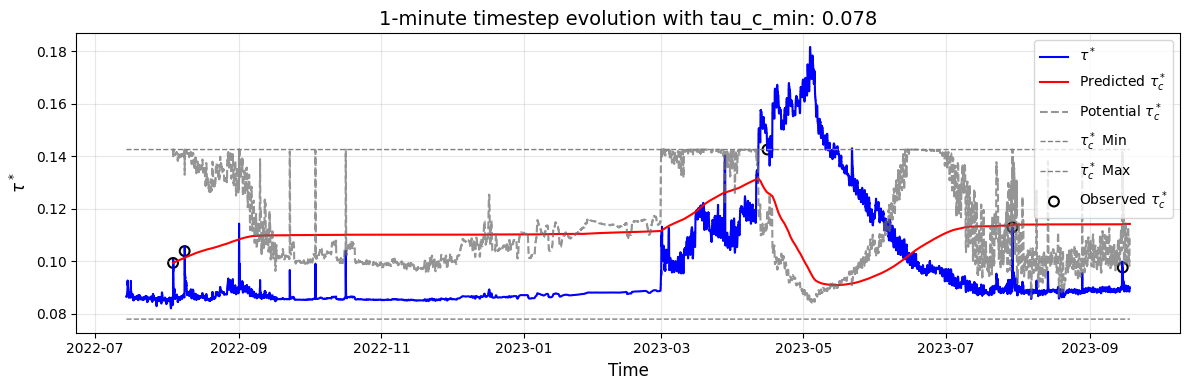

In [47]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.007271
10% threshold (<=): 0.007998
Parameter sets within threshold: 5 / 2000


,tau_c_min,A,B,MAE
0,0.078,0.000049,4.081633,0.007271
1,0.078,0.000070,5.102041,0.007320
2,0.078,0.000035,4.081633,0.007608
3,0.078,0.000070,4.081633,0.007865
4,0.078,0.000049,3.061224,0.007955


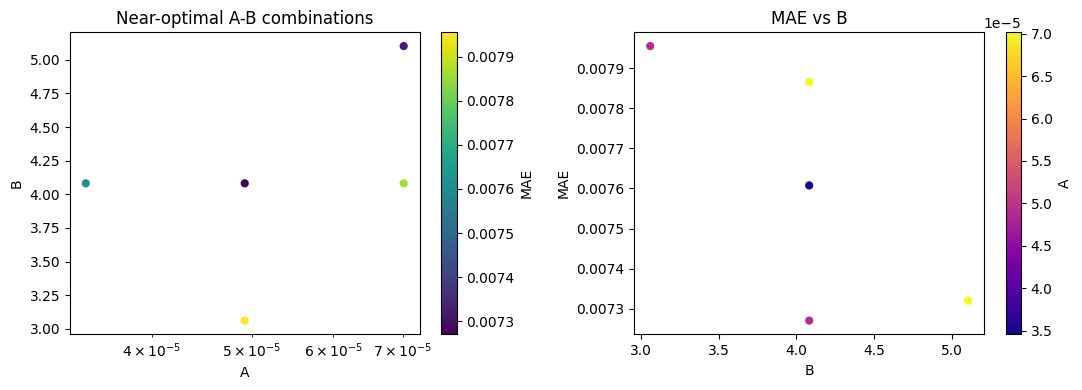

In [48]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.078.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.079

In [49]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.079

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


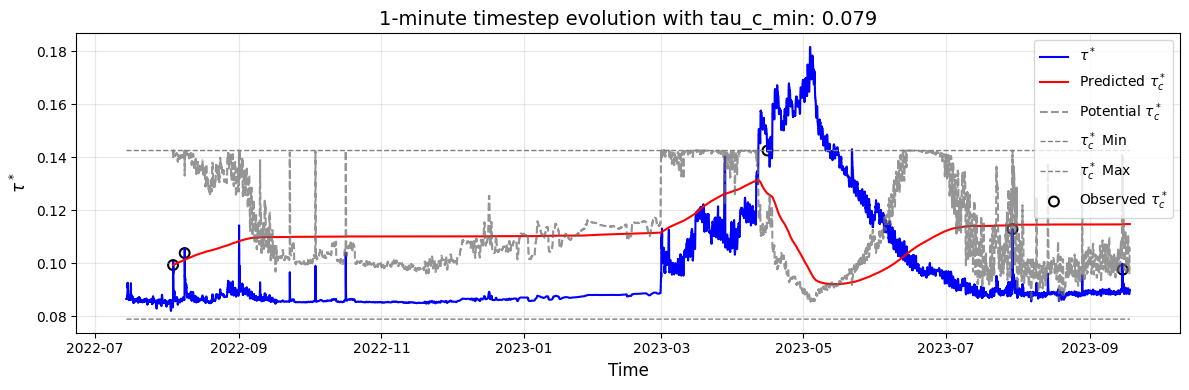

In [50]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.007486
10% threshold (<=): 0.008234
Parameter sets within threshold: 7 / 2000


,tau_c_min,A,B,MAE
0,0.079,0.000049,4.081633,0.007486
1,0.079,0.000070,5.102041,0.007497
2,0.079,0.000035,4.081633,0.007538
3,0.079,0.000049,5.102041,0.007893
4,0.079,0.000070,4.081633,0.008118
5,0.079,0.000049,3.061224,0.008187
6,0.079,0.000024,4.081633,0.008223


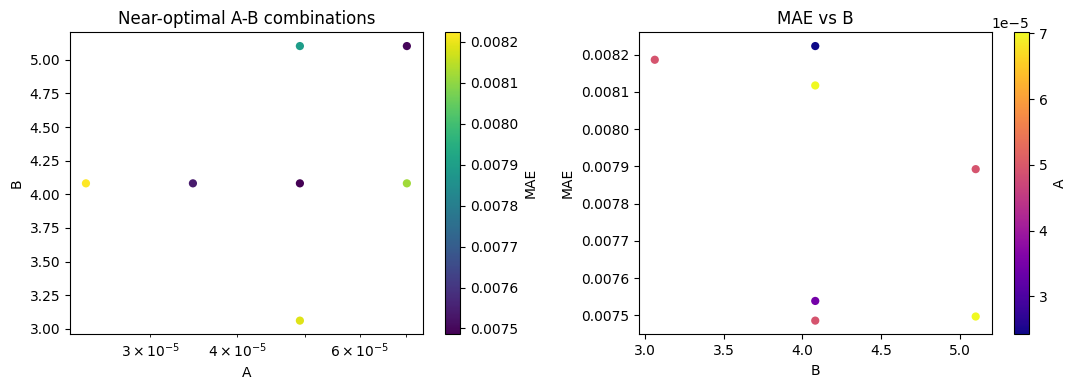

In [51]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.079.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.081

In [52]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.081

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


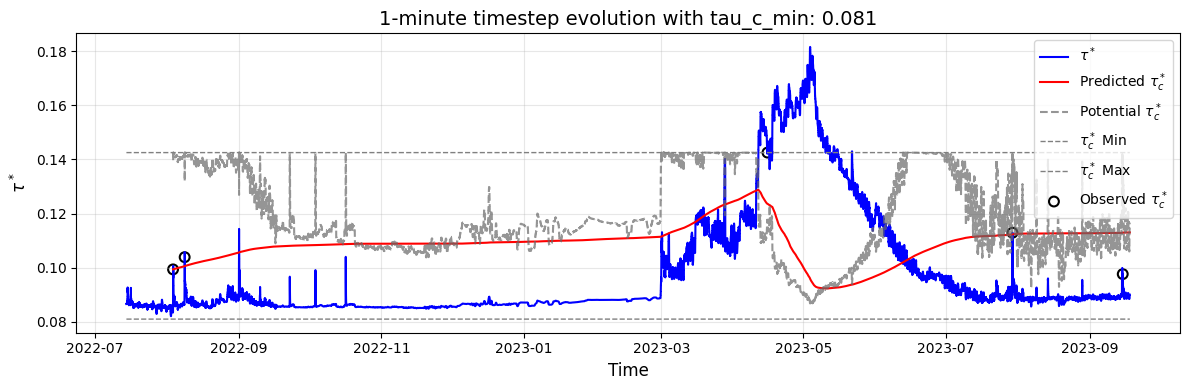

In [53]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.007643
10% threshold (<=): 0.008407
Parameter sets within threshold: 6 / 2000


,tau_c_min,A,B,MAE
0,0.081,0.000049,5.102041,0.007643
1,0.081,0.000070,6.122449,0.007966
2,0.081,0.000049,4.081633,0.007968
3,0.081,0.000035,4.081633,0.007970
4,0.081,0.000070,5.102041,0.007985
5,0.081,0.000024,4.081633,0.008279


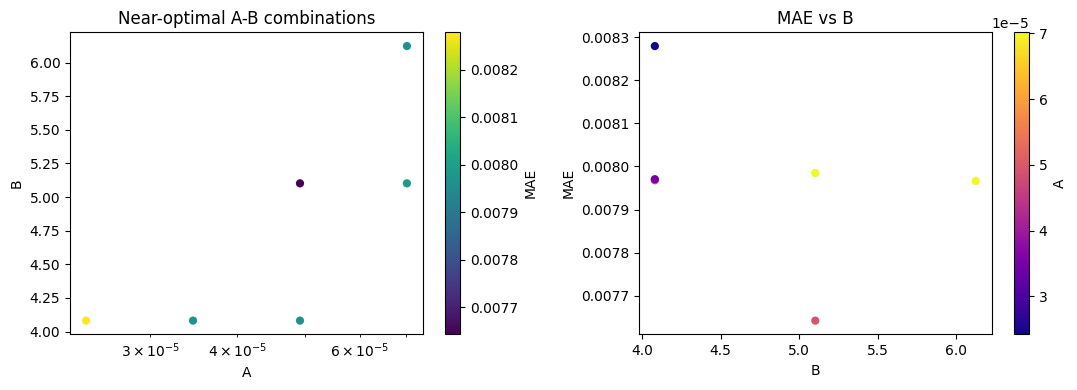

In [54]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.081.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.082

In [55]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.082

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


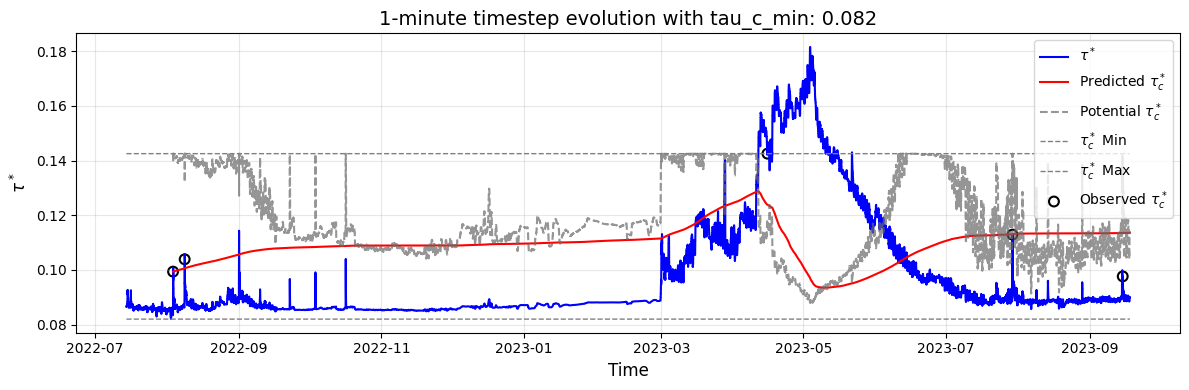

In [56]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.007604
10% threshold (<=): 0.008365
Parameter sets within threshold: 6 / 2000


,tau_c_min,A,B,MAE
0,0.082,0.000049,5.102041,0.007604
1,0.082,0.000070,6.122449,0.007840
2,0.082,0.000035,4.081633,0.008209
3,0.082,0.000049,4.081633,0.008225
4,0.082,0.000070,5.102041,0.008252
5,0.082,0.000035,5.102041,0.008273


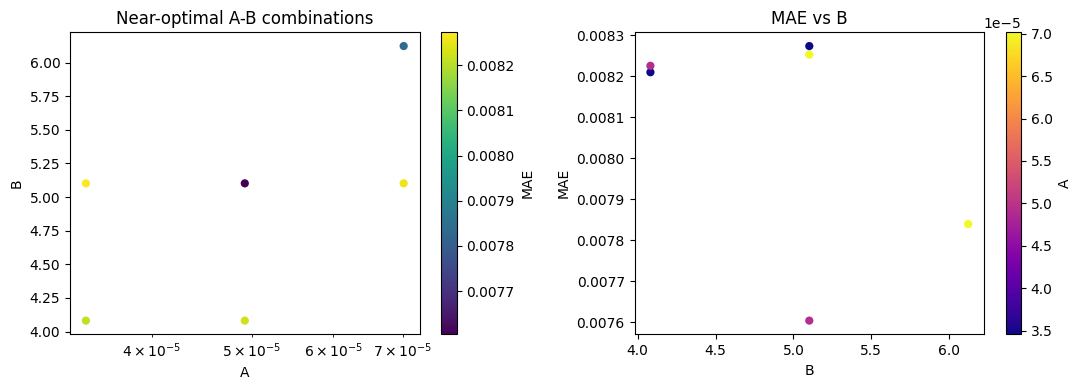

In [57]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.082.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.083

In [58]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.083

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


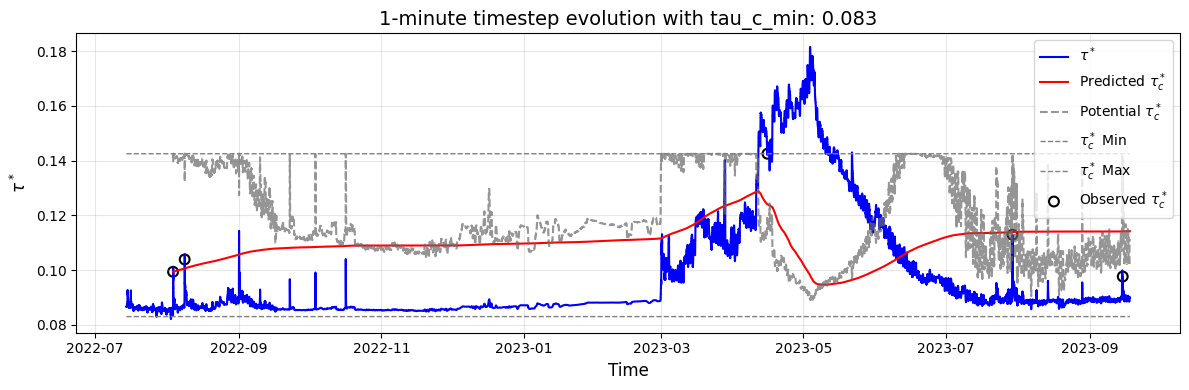

In [59]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.007852
10% threshold (<=): 0.008637
Parameter sets within threshold: 7 / 2000


,tau_c_min,A,B,MAE
0,0.083,0.000049,5.102041,0.007852
1,0.083,0.000070,6.122449,0.007992
2,0.083,0.000035,5.102041,0.008159
3,0.083,0.000035,4.081633,0.008452
4,0.083,0.000049,6.122449,0.008468
5,0.083,0.000049,4.081633,0.008479
6,0.083,0.000070,5.102041,0.008528


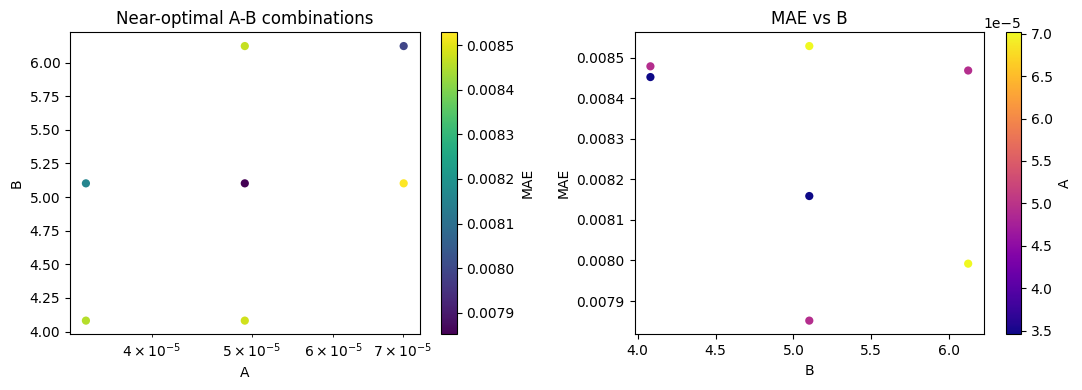

In [60]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.083.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.084

In [61]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.084

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


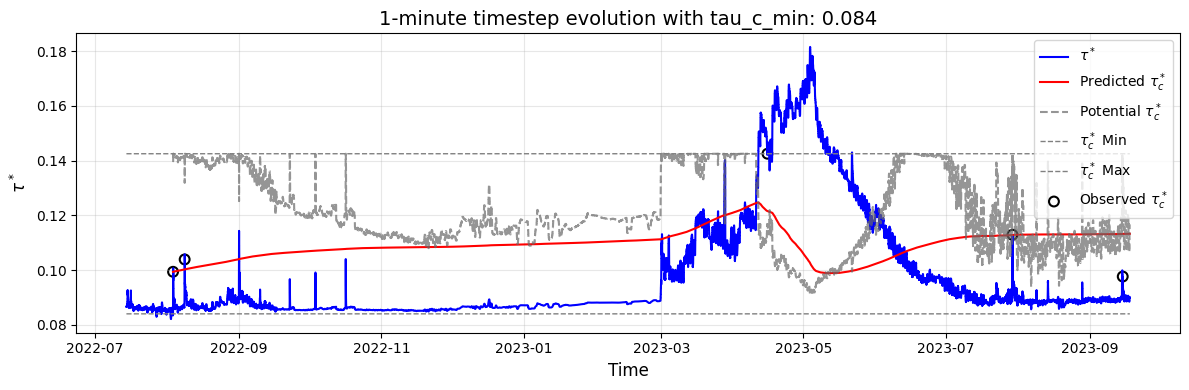

In [62]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.008068
10% threshold (<=): 0.008875
Parameter sets within threshold: 9 / 2000


,tau_c_min,A,B,MAE
0,0.084,0.000035,5.102041,0.008068
1,0.084,0.000049,5.102041,0.008117
2,0.084,0.000070,6.122449,0.008277
3,0.084,0.000049,6.122449,0.008309
4,0.084,0.000070,7.142857,0.008546
5,0.084,0.000035,4.081633,0.008704
6,0.084,0.000049,4.081633,0.008732
7,0.084,0.000024,5.102041,0.008765
8,0.084,0.000070,5.102041,0.008802


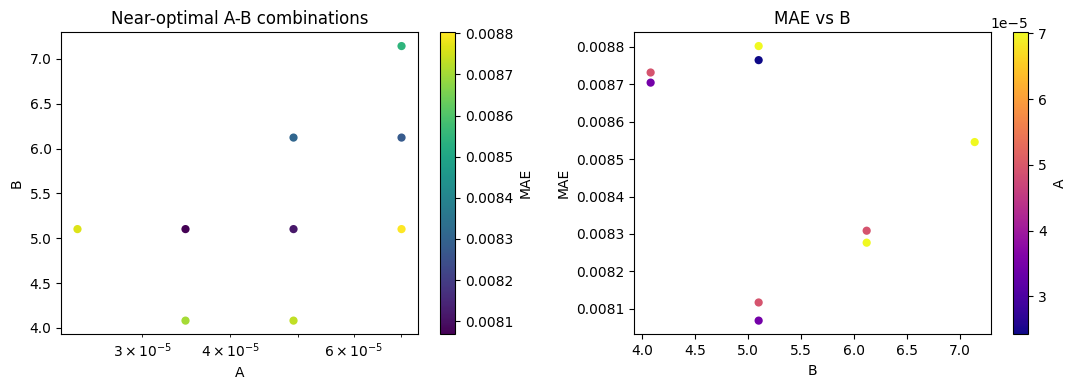

In [63]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.084.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

Best MAE: 0.008068
10% threshold (<=): 0.008875
Parameter sets within threshold: 9 / 2000


,tau_c_min,A,B,MAE
0,0.084,0.000035,5.102041,0.008068
1,0.084,0.000049,5.102041,0.008117
2,0.084,0.000070,6.122449,0.008277
3,0.084,0.000049,6.122449,0.008309
4,0.084,0.000070,7.142857,0.008546
5,0.084,0.000035,4.081633,0.008704
6,0.084,0.000049,4.081633,0.008732
7,0.084,0.000024,5.102041,0.008765
8,0.084,0.000070,5.102041,0.008802


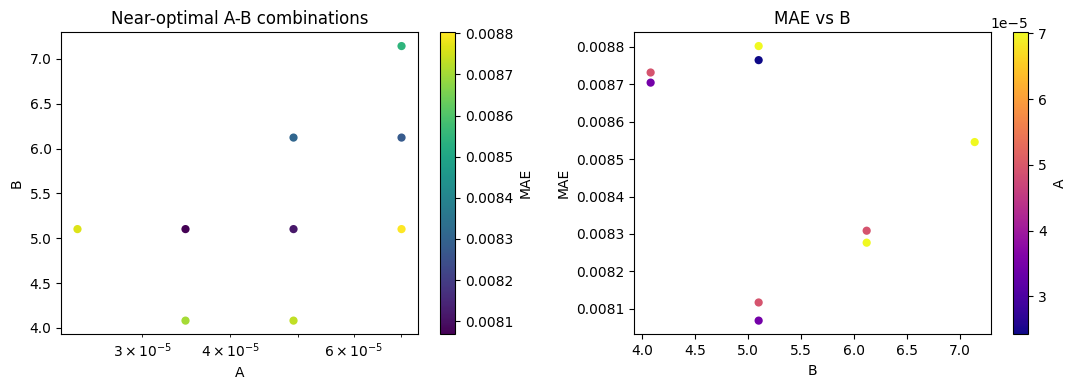

In [64]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.083.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.085

In [65]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.085

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


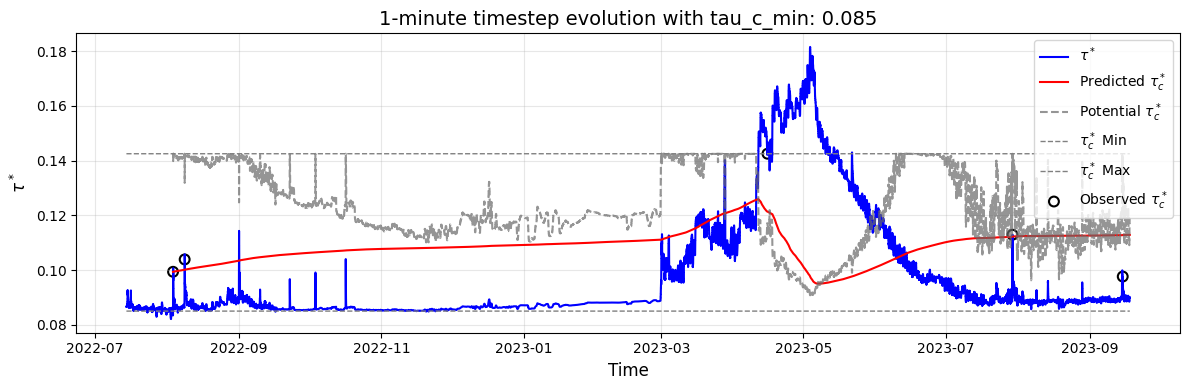

In [66]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.008172
10% threshold (<=): 0.008990
Parameter sets within threshold: 9 / 2000


,tau_c_min,A,B,MAE
0,0.085,0.000049,6.122449,0.008172
1,0.085,0.000035,5.102041,0.008264
2,0.085,0.000070,7.142857,0.008390
3,0.085,0.000049,5.102041,0.008393
4,0.085,0.000070,6.122449,0.008575
5,0.085,0.000024,5.102041,0.008677
6,0.085,0.000035,6.122449,0.008948
7,0.085,0.000035,4.081633,0.008954
8,0.085,0.000049,4.081633,0.008973


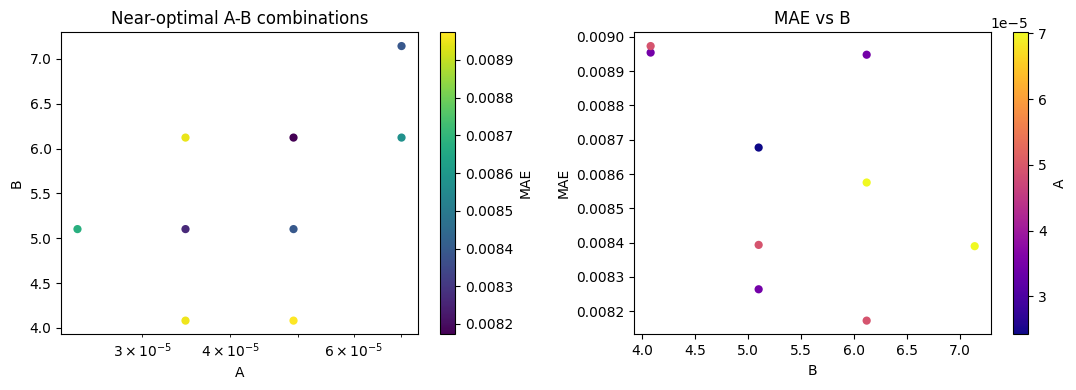

In [67]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.085.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.086

In [68]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.086

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


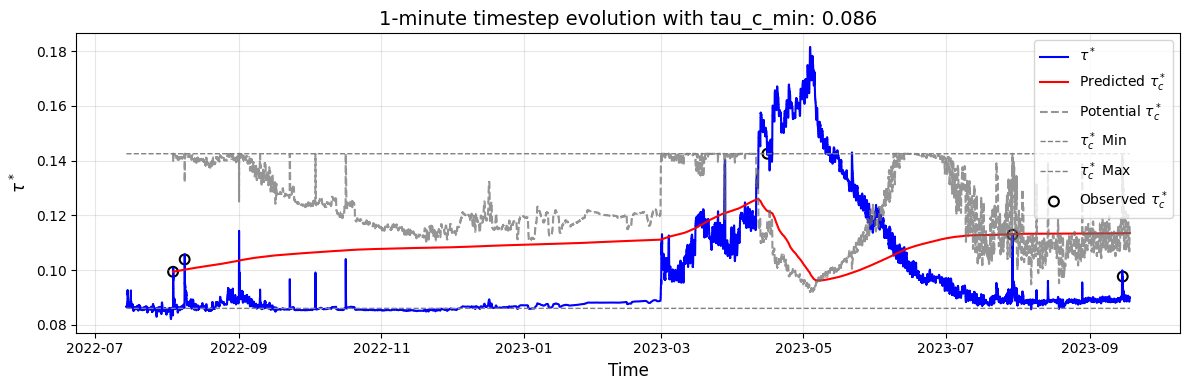

In [69]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.008140
10% threshold (<=): 0.008954
Parameter sets within threshold: 7 / 2000


,tau_c_min,A,B,MAE
0,0.086,0.000049,6.122449,0.008140
1,0.086,0.000070,7.142857,0.008467
2,0.086,0.000035,5.102041,0.008528
3,0.086,0.000049,5.102041,0.008677
4,0.086,0.000024,5.102041,0.008695
5,0.086,0.000035,6.122449,0.008815
6,0.086,0.000070,6.122449,0.008883


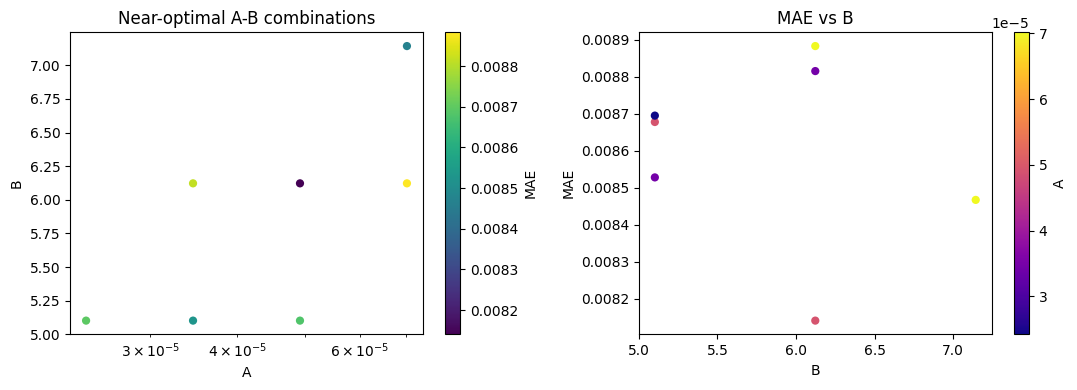

In [70]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.086.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.087

In [71]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.087

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


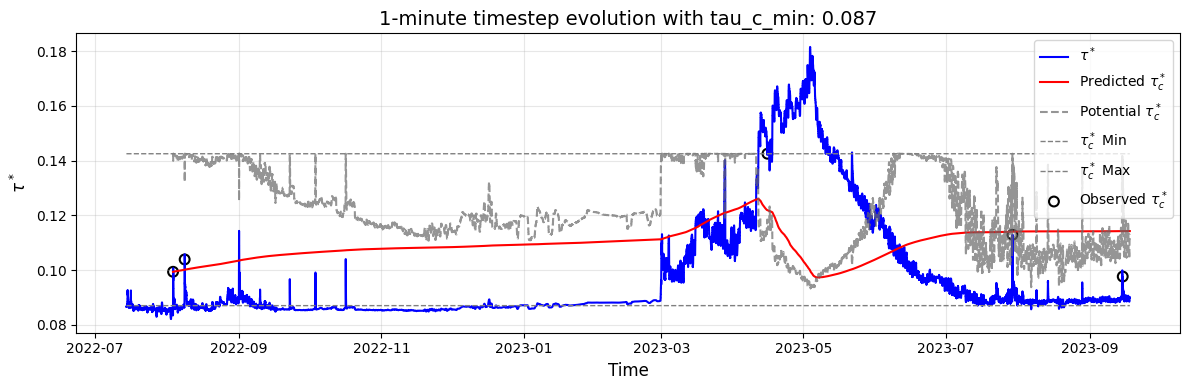

In [72]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.008429
10% threshold (<=): 0.009271
Parameter sets within threshold: 10 / 2000


,tau_c_min,A,B,MAE
0,0.087,0.000049,6.122449,0.008429
1,0.087,0.000035,6.122449,0.008693
2,0.087,0.000070,7.142857,0.008789
3,0.087,0.000035,5.102041,0.008803
4,0.087,0.000049,7.142857,0.008877
5,0.087,0.000024,5.102041,0.008938
6,0.087,0.000049,5.102041,0.008964
7,0.087,0.000070,8.163265,0.009041
8,0.087,0.000070,6.122449,0.009193
9,0.087,0.000017,5.102041,0.009263


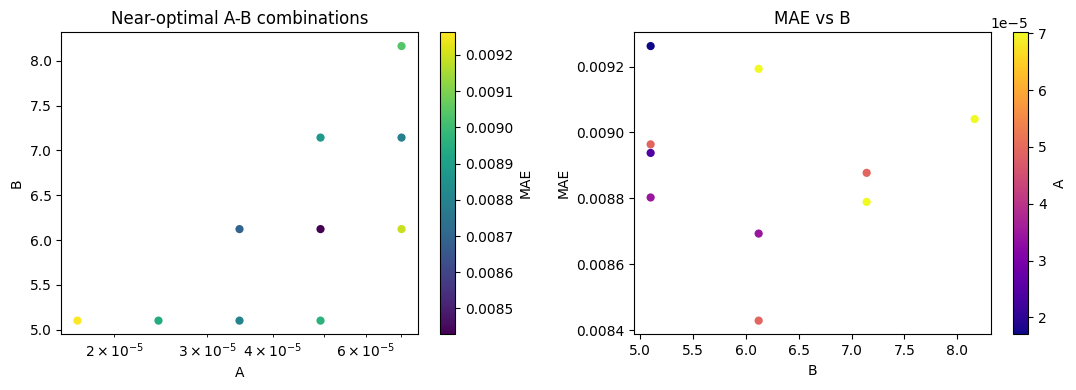

In [73]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.087.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.088

In [74]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.088

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


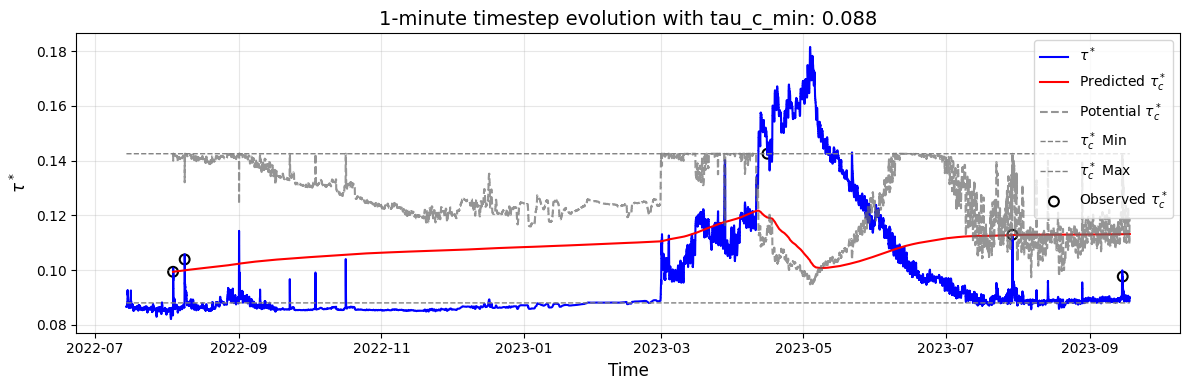

In [75]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.008591
10% threshold (<=): 0.009450
Parameter sets within threshold: 10 / 2000


,tau_c_min,A,B,MAE
0,0.088,0.000035,6.122449,0.008591
1,0.088,0.000049,6.122449,0.008736
2,0.088,0.000049,7.142857,0.008738
3,0.088,0.000070,8.163265,0.008899
4,0.088,0.000035,5.102041,0.009083
5,0.088,0.000070,7.142857,0.009129
6,0.088,0.000024,5.102041,0.009191
7,0.088,0.000049,5.102041,0.009251
8,0.088,0.000017,5.102041,0.009371
9,0.088,0.000024,6.122449,0.009389


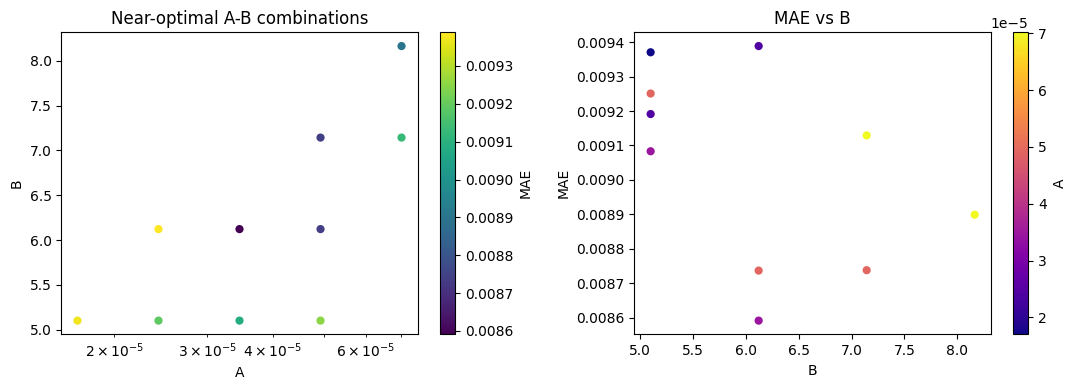

In [76]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.088.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.089

In [77]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.089

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


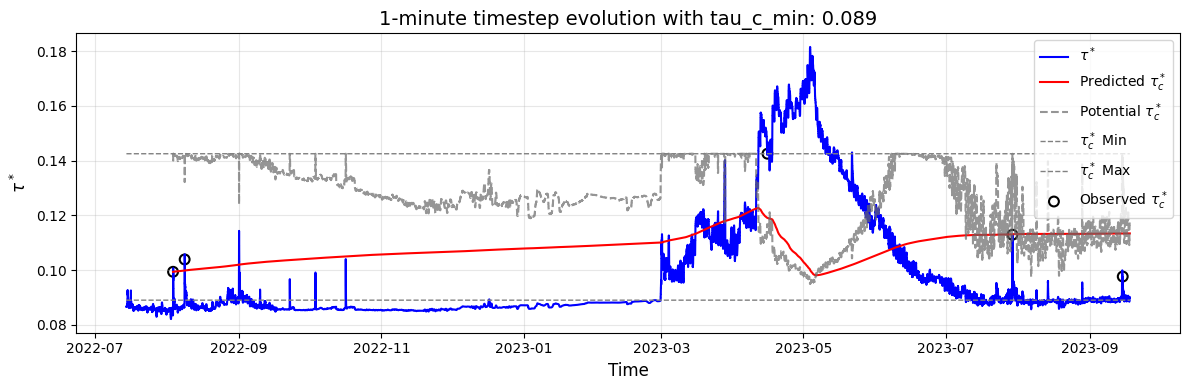

In [78]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.008685
10% threshold (<=): 0.009554
Parameter sets within threshold: 10 / 2000


,tau_c_min,A,B,MAE
0,0.089,0.000049,7.142857,0.008685
1,0.089,0.000035,6.122449,0.008813
2,0.089,0.000049,6.122449,0.009055
3,0.089,0.000070,8.163265,0.009243
4,0.089,0.000024,6.122449,0.009298
5,0.089,0.000035,5.102041,0.009368
6,0.089,0.000024,5.102041,0.009450
7,0.089,0.000070,7.142857,0.009476
8,0.089,0.000035,7.142857,0.009476
9,0.089,0.000049,5.102041,0.009531


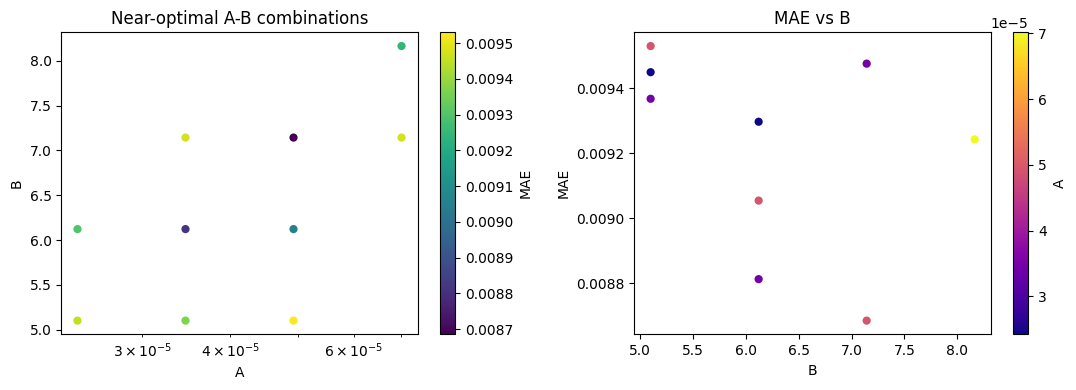

In [79]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.089.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.09

In [80]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.09

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


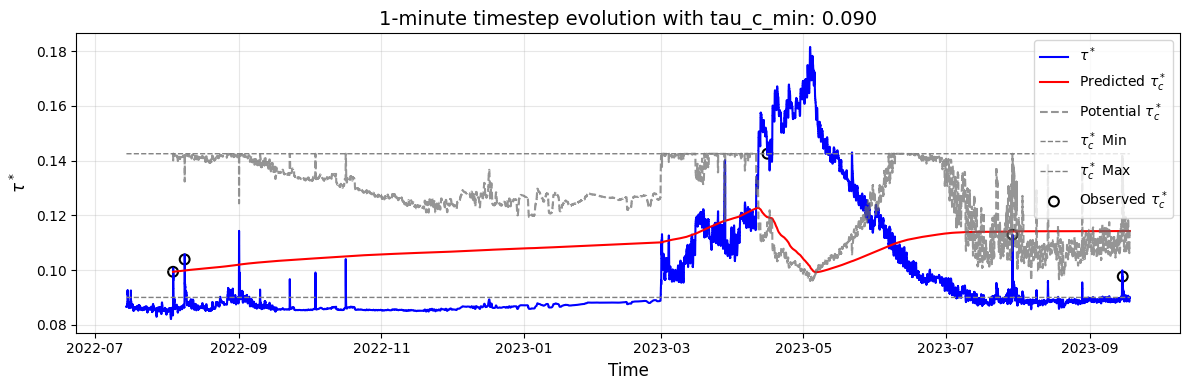

In [81]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.009013
10% threshold (<=): 0.009914
Parameter sets within threshold: 14 / 2000


,tau_c_min,A,B,MAE
0,0.09,0.000049,7.142857,0.009013
1,0.09,0.000035,6.122449,0.009115
2,0.09,0.000024,6.122449,0.009219
3,0.09,0.000035,7.142857,0.009365
4,0.09,0.000049,6.122449,0.009378
5,0.09,0.000049,8.163265,0.009482
6,0.09,0.000070,8.163265,0.009613
7,0.09,0.000070,9.183673,0.009643
8,0.09,0.000035,5.102041,0.009650
9,0.09,0.000024,5.102041,0.009711


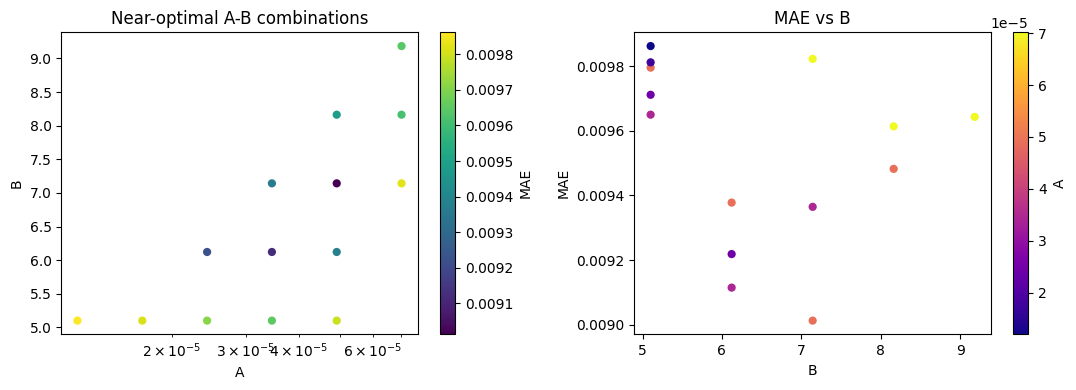

In [82]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.090.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.091

In [83]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.091

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


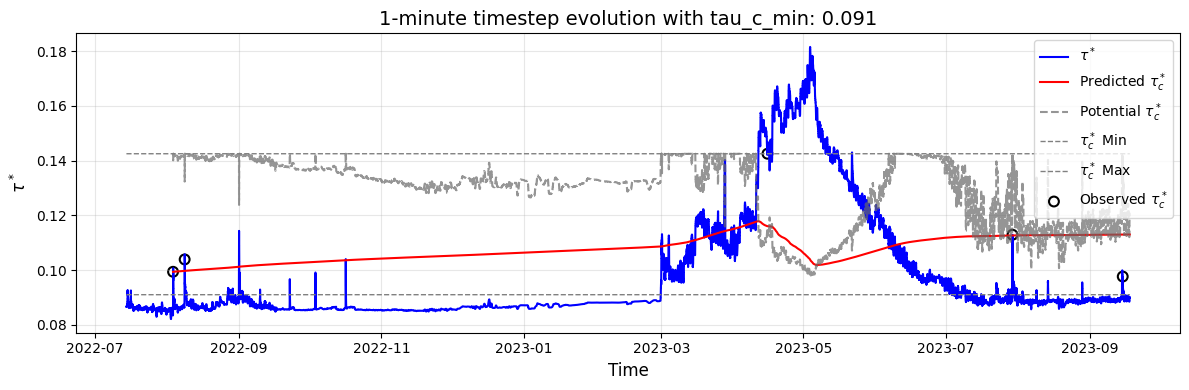

In [84]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.009261
10% threshold (<=): 0.010188
Parameter sets within threshold: 16 / 2000


,tau_c_min,A,B,MAE
0,0.091,0.000035,7.142857,0.009261
1,0.091,0.000049,7.142857,0.009359
2,0.091,0.000049,8.163265,0.009361
3,0.091,0.000035,6.122449,0.009427
4,0.091,0.000024,6.122449,0.009472
5,0.091,0.000049,6.122449,0.009698
6,0.091,0.000035,5.102041,0.009926
7,0.091,0.000017,6.122449,0.009961
8,0.091,0.000024,5.102041,0.009972
9,0.091,0.000070,8.163265,0.009991


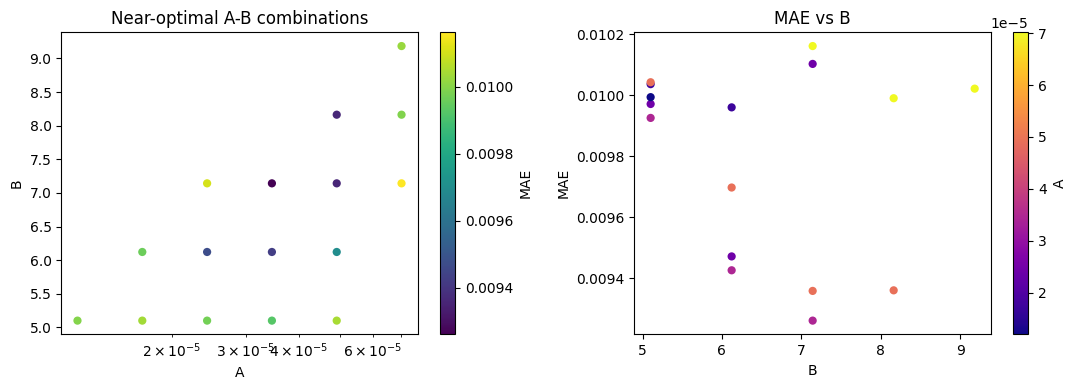

In [85]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.091.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.092

In [86]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.092

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


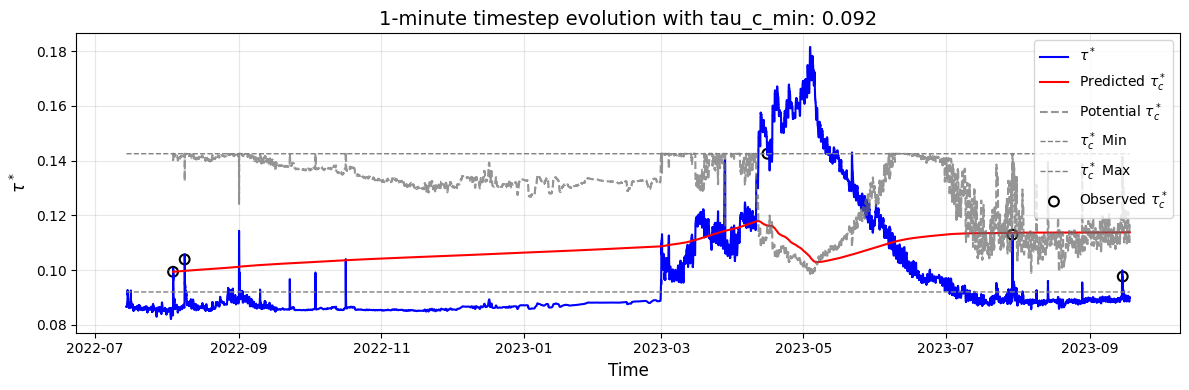

In [87]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.009459
10% threshold (<=): 0.010405
Parameter sets within threshold: 18 / 2000


,tau_c_min,A,B,MAE
0,0.092,0.000035,7.142857,0.009459
1,0.092,0.000049,8.163265,0.009636
2,0.092,0.000049,7.142857,0.009712
3,0.092,0.000035,6.122449,0.009742
4,0.092,0.000024,6.122449,0.009753
5,0.092,0.000017,6.122449,0.009901
6,0.092,0.000049,6.122449,0.010011
7,0.092,0.000024,7.142857,0.010022
8,0.092,0.000035,8.163265,0.010111
9,0.092,0.000049,9.183673,0.010159


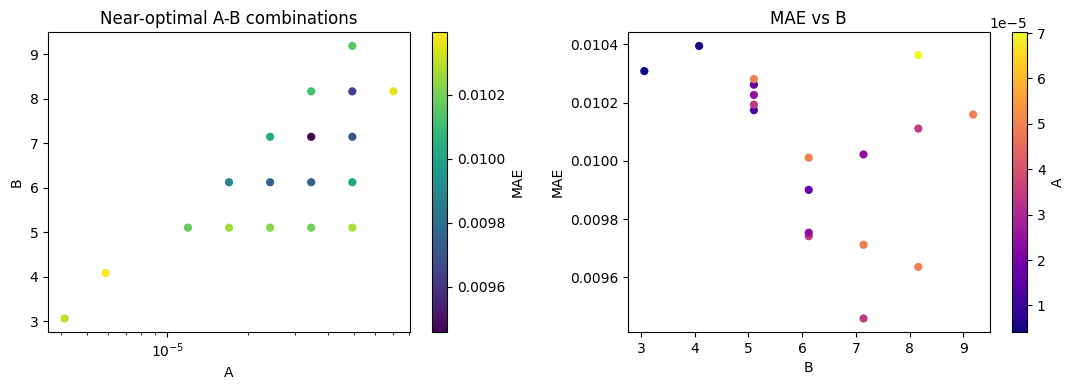

In [88]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.092.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

0.093

In [89]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.093

calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/40)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.959184

C:\Users\huck4481\AppData\Local\Temp\ipykernel_27016\1974042757.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\huck4481\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


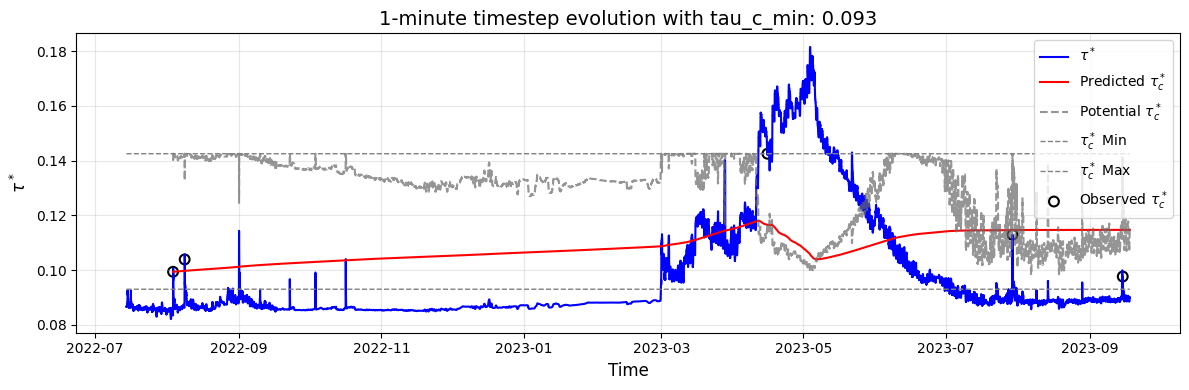

In [90]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with tau_c_min: {:.3f}".format(best["tau_c_min"]), fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.009792
10% threshold (<=): 0.010771
Parameter sets within threshold: 31 / 2000

Top 30 by MAE:


,tau_c_min,A,B,MAE
0,0.093,0.000035,7.142857,0.009792
1,0.093,0.000024,7.142857,0.009945
2,0.093,0.000049,8.163265,0.010006
3,0.093,0.000035,8.163265,0.010015
4,0.093,0.000024,6.122449,0.010041
5,0.093,0.000017,6.122449,0.010042
6,0.093,0.000035,6.122449,0.010054
7,0.093,0.000049,7.142857,0.010064
8,0.093,0.000049,9.183673,0.010098
9,0.093,0.000049,6.122449,0.010311


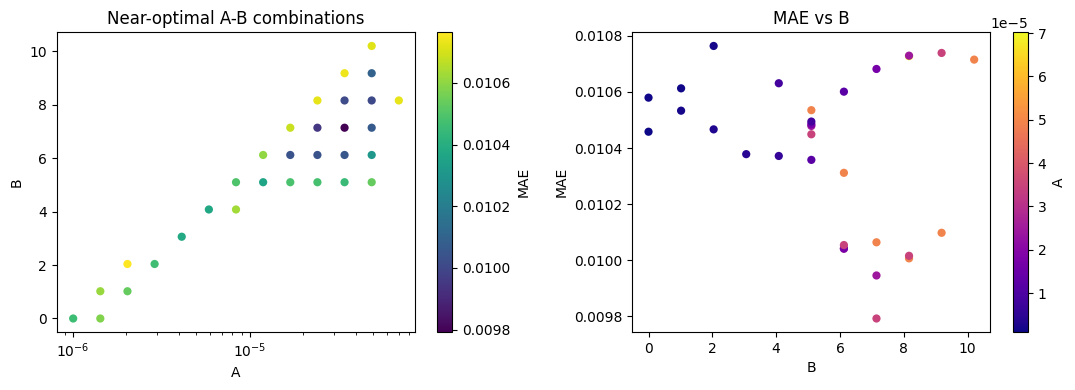

In [91]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/dt=1/tc_min_0.093.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()